# Stock Selection Decision Support Tool for Shooting Star Capital

This notebook develops a decision support tool for stock selection and portfolio design for Shooting Star Capital.

The analysis follows the four tasks required in the assignment:

1. Set up a SQLite database and transfer the information contained in the `.txt` files to the database.
2. Determine the average return per sector in 2025, based on each company’s market capitalization and using 2024’s last closing price as the reference point for computing returns in 2025.
3. Formulate the portfolio composition problem as a mathematical optimization model, solve it using Gurobi, and determine the composition of the fund.
4. Analyze the sensitivity of the portfolio’s performance to the imposed investment strategy.


## 1. SQLite Database and Data Transfer

Administering a collection of `.txt` files is inconvenient for a decision support tool. Therefore, the information contained in the files is transferred to a SQLite database.

Each file contains:
- the stock identifier,
- the industry sector of the respective company,
- the number of shares,
- the stock’s daily closing prices of the entire past year.

The database is designed to store stock information and daily prices in a structured way, so that the data can later be queried and analyzed efficiently.


## 1.1 - Importing Required Libraries
The main tools used are:
- **pandas** for data manipulation
- **sqlite3** for database management
- **matplotlib** for visualization
- **gurobipy** for solving the optimization problem

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum
import matplotlib.pyplot as plt


## 1.2 - Database Construction
The dataset consists of several `.txt` files, each describing a stock. Each file contains:
- Stock identifier
- Industry sector
- Number of outstanding shares
- Daily price observations

To efficiently manage this information, I store the data inside an **SQLite relational database**. The database contains two tables:

**stocks**

| column | description |
|--------|-------------|
| stockid | unique identifier |
| sector | industry sector |
| shares | number of outstanding shares |

**prices**

| column | description |
|--------|-------------|
| stock_id | stock identifier |
| date | observation date |
| price | closing price |

In [2]:
# creating SQLite database
conn = sqlite3.connect("stocks.db")
cursor = conn.cursor()

# creating table for stock information
cursor.execute("""
CREATE TABLE IF NOT EXISTS stocks(
    stock_id TEXT PRIMARY KEY,
    sector TEXT,
    shares INTEGER
)
""")

# creating table for daily prices
cursor.execute("""
CREATE TABLE IF NOT EXISTS prices(
    stock_id TEXT,
    date TEXT,
    price REAL,
    PRIMARY KEY (stock_id, date),
    FOREIGN KEY (stock_id) REFERENCES stocks(stock_id)
)
""")

# useful indexes for queries and joins
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_stocks_sector
ON stocks(sector)
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_prices_stock_date
ON prices(stock_id, date)
""")

conn.commit()


## 1.3 - Data Import

Each text file in the dataset corresponds to a specific stock. The import procedure performs the following steps:

1. Read each `.txt` file
2. Extract stock metadata (ID, sector, shares)
3. Extract daily price observations
4. Store the information inside the SQLite database

In [3]:
# data path
data_folder = "Data"

for file in os.listdir(data_folder):
    if file.endswith(".txt"):
        path = os.path.join(data_folder, file)

        with open(path, "r") as f:
            lines = f.read().splitlines()

        # extracting stock information
        stock_id = lines[1]
        sector = lines[3]
        shares = int(lines[5])

        # inserting stock metadata
        cursor.execute(
            "INSERT OR REPLACE INTO stocks VALUES (?, ?, ?)",
            (stock_id, sector, shares)
        )

        # inserting daily prices
        for row in lines[7:]:
            date, price = row.split(";")

            cursor.execute(
                "INSERT OR REPLACE INTO prices VALUES (?, ?, ?)",
                (stock_id, date, float(price))
            )

conn.commit()
conn.close()


## 1.4 - Loading Data

After constructing the database, I load the information into pandas DataFrames to perform the financial analysis. Two datasets are retrieved:
- stock metadata
- historical price data

In [4]:
# connecting
conn = sqlite3.connect("stocks.db")

stocks = pd.read_sql("SELECT * FROM stocks", conn)
prices = pd.read_sql("SELECT * FROM prices", conn)

prices["date"] = pd.to_datetime(prices["date"])

# printing example
stocks.head()

,stock_id,sector,shares
0,012CB0Y3,construction,396377792
1,01G6OXE8,AI,635684123
2,078MJL7Y,healthcare,996400445
3,0BRJWGDC,electronics,326728839
4,0CZELTC3,electronics,25163941


## 1.5 – Flexible Data Query
The user shall be able to filter for stocks based on:
- their industry sector, and
- their last known closing price.

Specifically, the tool allows the retrieval of stocks whose last known closing price exceeds a user-specified threshold.



In [5]:
# creating a function 
def query_stocks(conn, sectors=None, min_price=None):
    query = """
    WITH latest_prices AS (
        SELECT p1.stock_id, p1.date, p1.price
        FROM prices p1
        JOIN (
            SELECT stock_id, MAX(date) AS max_date
            FROM prices
            GROUP BY stock_id
        ) p2
        ON p1.stock_id = p2.stock_id AND p1.date = p2.max_date
    )
    SELECT s.stock_id, s.sector, s.shares, lp.price
    FROM stocks s
    JOIN latest_prices lp ON s.stock_id = lp.stock_id
    """

    conditions = []
    params = []

    if sectors is not None and len(sectors) > 0:
        placeholders = ",".join(["?"] * len(sectors))
        conditions.append(f"s.sector IN ({placeholders})")
        params.extend(sectors)

    if min_price is not None:
        conditions.append("lp.price >= ?")
        params.append(min_price)

    if conditions:
        query += " WHERE " + " AND ".join(conditions)

    return pd.read_sql(query, conn, params=params)


In [6]:
# usage
conn = sqlite3.connect("stocks.db")
filtered = query_stocks(conn, sectors=["AI"], min_price=100)
filtered.head()




,stock_id,sector,shares,price
0,01G6OXE8,AI,635684123,104.56
1,01G6OXE8,AI,635684123,104.56
2,01G6OXE8,AI,635684123,104.56
3,01G6OXE8,AI,635684123,104.56
4,01G6OXE8,AI,635684123,104.56


In [7]:
stocks["sector"].unique()


array(['construction', 'AI', 'healthcare', 'electronics', 'communication',
       'insurance', 'food', 'mobility', 'education', 'logistics',
       'fashion', 'entertainment', 'biotechnology', 'pharmaceuticals',
       'materials', 'finance', 'engineering', 'marketing', 'lifestyle',
       'energy'], dtype=object)

## 2. Sector Performance in 2025

As there has not been any specific management order to focus on certain sectors or stocks, the entire market is included in the analysis.

To obtain an overview of each sector’s performance in 2025, the average return per sector is determined. This average is based on:
1. each company’s market capitalization, and
2. the assumption that 2024’s last closing price of a stock is the reference point for computing its return in 2025.


## 2.1 - Return Computation

The stock return for 2025  measures the relative performance of each stock during the considered time horizon, ant it is computed using the first and last available prices in the dataset. The first observed price is assumed to correspond to the last closing price of 2024. It is defined as:

Return = (P_end - P_start) / P_start

where:

- P_start is the price at the beginning of the period
- P_end is the price at the end of the period

In [8]:
# sorting by stock and date
prices = prices.sort_values(["stock_id", "date"]).copy()

# first available price for each stock
# in this dataset it corresponds to the last closing price of 2024
start_prices = prices.groupby("stock_id").first().reset_index()

# last available price for each stock
# in this dataset it corresponds to the last available closing price in 2025
end_prices = prices.groupby("stock_id").last().reset_index()

# merging in a new table
returns = start_prices[["stock_id", "price"]].merge(
    end_prices[["stock_id", "price"]],
    on="stock_id",
    suffixes=("_start", "_end")
)

# computing return in 2025
returns["return"] = (returns["price_end"] - returns["price_start"]) / returns["price_start"]

returns.head()


,stock_id,price_start,price_end,return
0,012CB0Y3,469.55,185.88,-0.604132
1,01G6OXE8,137.07,104.56,-0.237178
2,078MJL7Y,65.33,30.14,-0.538650
3,0BRJWGDC,215.18,145.03,-0.326006
4,0CZELTC3,70.27,58.95,-0.161093


## 2.2 - Return Distribution
To better understand the characteristics of the dataset, the distribution of individual stock returns in 2025 is visualized. This provides insight into the variability of stock performance across the market.


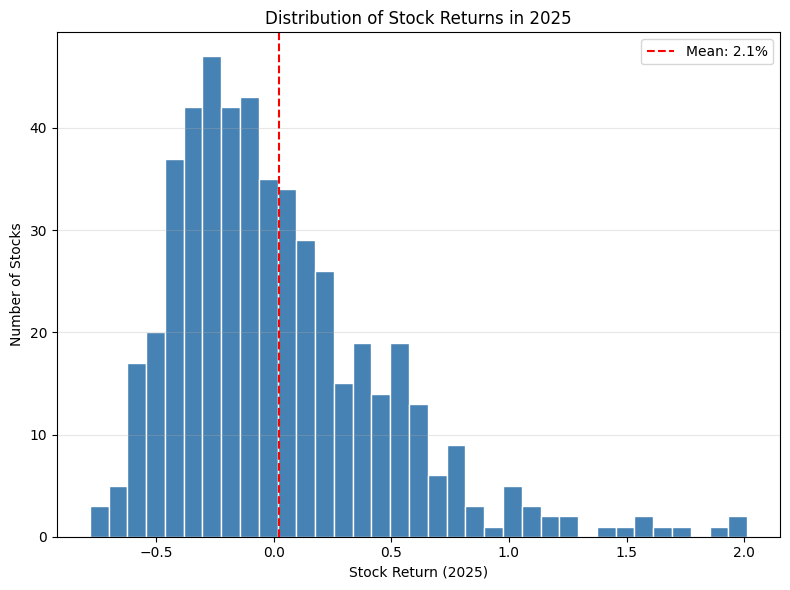

In [9]:
data = returns["return"]

plt.figure(figsize=(8,6))

plt.hist(data,bins=35,color="steelblue",edgecolor="white")

# mean line
mean_return = data.mean()
plt.axvline(mean_return, color="red", linestyle="--", label=f"Mean: {mean_return:.1%}")

plt.xlabel("Stock Return (2025)")
plt.ylabel("Number of Stocks")
plt.title("Distribution of Stock Returns in 2025")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()


## 2.3 - Sector Composition

The following chart shows how many companies belong to each sector in the dataset.


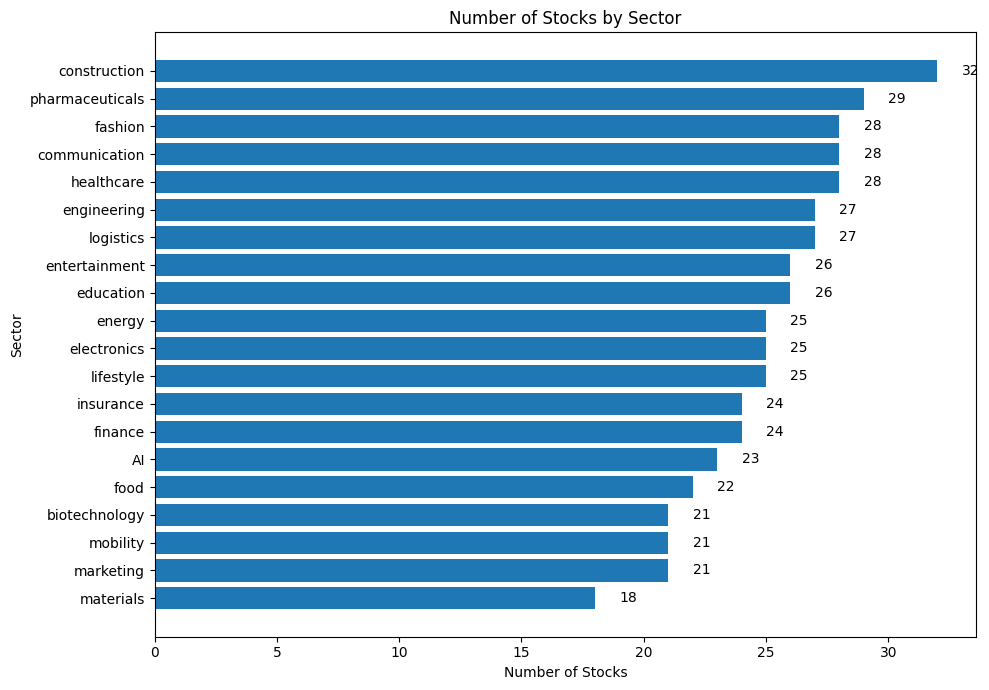

In [10]:
sector_counts = stocks["sector"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(sector_counts.index, sector_counts.values)

plt.xlabel("Number of Stocks")
plt.ylabel("Sector")
plt.title("Number of Stocks by Sector")

for bar, value in zip(bars, sector_counts.values):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(value), va="center")

plt.tight_layout()
plt.show()


## 2.4 - Sector Performance Analysis

To analyze sector performance, I will compute the **average return per sector**. However, instead of using a simple mean, we compute a **market-capitalization weighted return**: using market capitalization allows larger firms to have a greater influence on the sector return. 

It is defined as:

MarketCap = Shares × Price


In [11]:
# merging stock info and returns
df = returns.merge(stocks, on="stock_id")

# computing market capitalization
df["marketcap"] = df["shares"] * df["price_start"]

# weighted sector return
# group by sector, 
# then sum (return*marketcap) / sum(marketcap) 
sector_returns = (
    df.assign(weighted_return=df["return"] * df["marketcap"])
      .groupby("sector")
      .agg(
          total_marketcap=("marketcap", "sum"),
          avg_return=("weighted_return", lambda x: x.sum())
      )
      .reset_index()
)

sector_returns["avg_return"] = sector_returns["avg_return"] / sector_returns["total_marketcap"]


sector_returns

,sector,total_marketcap,avg_return
0,AI,2.589239e+12,0.276245
1,biotechnology,3.468805e+12,-0.084079
2,communication,3.728376e+12,0.062812
3,construction,2.831915e+12,0.036500
4,education,3.995027e+12,0.179557
5,electronics,2.792638e+12,-0.050759
6,energy,3.017779e+12,0.019262
7,engineering,3.167230e+12,-0.124594
8,entertainment,3.166956e+12,-0.075551
9,fashion,4.136523e+12,0.064943


## 2.5 - Sector Return Visualization

The following chart shows the average return of each sector. This visualization helps identify:

- high-performing sectors
- underperforming sectors

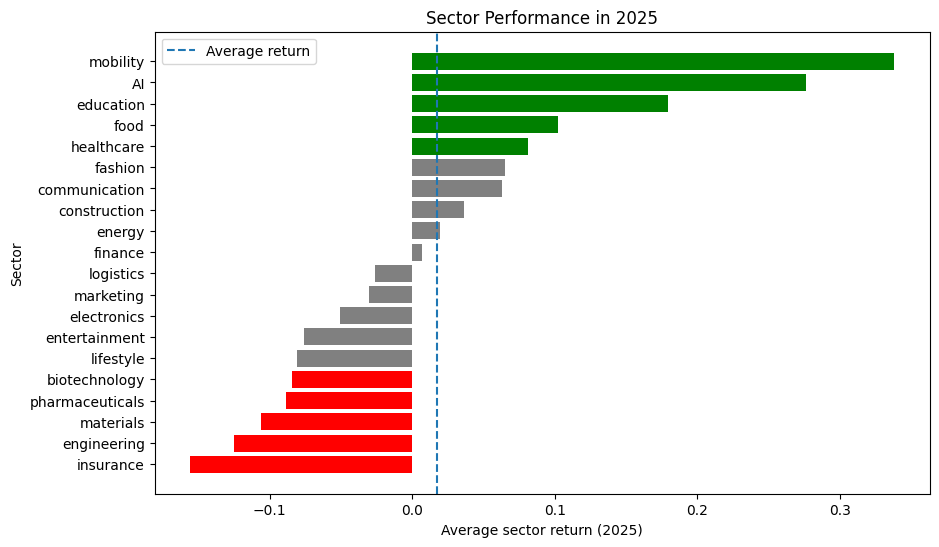

In [12]:
# sorting 
sector_returns = sector_returns.sort_values("avg_return")

# plotting
plt.figure(figsize=(10,6))

colors = []
for val in sector_returns["avg_return"]:
    if val >= sector_returns["avg_return"].quantile(0.75):
        colors.append("green")
    elif val <= sector_returns["avg_return"].quantile(0.25):
        colors.append("red")
    else:
        colors.append("gray")

plt.barh(sector_returns["sector"], sector_returns["avg_return"], color=colors)

plt.axvline(sector_returns["avg_return"].mean(),
            linestyle="--",
            label="Average return")

plt.xlabel("Average sector return (2025)")
plt.ylabel("Sector")
plt.title("Sector Performance in 2025")
plt.legend()

plt.show()


## 2.6 - Sector Classification

Sectors are divided into three groups based on their performance:

- **Top 25% sectors**
- **Middle 50% sectors**
- **Bottom 25% sectors**

This classification will guide the portfolio allocation.

In [13]:
# sorting desc
sector_returns = sector_returns.sort_values("avg_return", ascending=False)

# number of sector
n = len(sector_returns)

# computing 
top = sector_returns.iloc[:int(0.25*n)]["sector"].tolist()
bottom = sector_returns.iloc[-int(0.25*n):]["sector"].tolist()
middle = sector_returns.iloc[int(0.25*n):-int(0.25*n)]["sector"].tolist()

top, middle, bottom

(['mobility', 'AI', 'education', 'food', 'healthcare'],
 ['fashion',
  'communication',
  'construction',
  'energy',
  'finance',
  'logistics',
  'marketing',
  'electronics',
  'entertainment',
  'lifestyle'],
 ['biotechnology', 'pharmaceuticals', 'materials', 'engineering', 'insurance'])

## 3. Portfolio Composition Problem

With the stocks and sectors analyzed, the next step is to determine the composition of the fund.

Assuming that each stock’s performance in the near future is comparable to the one observed in 2025, the portfolio is designed under the following investment rules:
- 50% of the available capital is invested into the top 25% industry sectors,
- 20% of the available capital is invested into the bottom 25% industry sectors,
- 30% of the available capital is invested into the remaining 50% industry sectors.

To avoid company concentration risk, no more than 5% of the available capital is invested into a single company.

The overall goal is to maximize the return of the portfolio.


## 3.1 - Portfolio Optimization Model

The portfolio allocation is determined by solving an optimization problem.

**Decision variable:** x_i = fraction of capital invested in stock i

**Objective:** maximize expected portfolio return

**Maximize:** Σ r_i * x_i

**Constraints:**

1. Full investment: Σ x_i = 1

2. Maximum exposure per stock: x_i ≤ 0.05

3. Sector allocation constraints (Top sectors → 50% of capital; Middle sectors → 30%, Bottom sectors → 20%)

In [14]:
# stock as list
stocks_list = df["stock_id"].tolist()

# dictionary, in order to get the corrisponding value easier later
returns_dict = dict(zip(df["stock_id"], df["return"]))
sector_dict = dict(zip(df["stock_id"], df["sector"]))

# matematical model
model = Model()

# xi = fraction of investment in i  
# decision variables, lower and upper bound
x = model.addVars(stocks_list, lb=0, ub=0.05)

# objective function: maximazing return * investment 
model.setObjective(
    quicksum(returns_dict[i] * x[i] for i in stocks_list),
    GRB.MAXIMIZE
)

# full investment: total sum xi = 1
model.addConstr(quicksum(x[i] for i in stocks_list) == 1)

# sector constraints
model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in top) == 0.5)
model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in middle) == 0.3)
model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in bottom) == 0.2)

# solce model
model.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 4 rows, 500 columns and 1000 nonzeros (Max)
Model fingerprint: 0x981c948d
Model has 500 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e-04, 2e+00]
  Bounds range     [5e-02, 5e-02]
  RHS range        [2e-01, 1e+00]

Presolve time: 0.04s
Presolved: 4 rows, 500 columns, 1000 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.9167938e+00   8.500000e-01   0.000000e+00      0s
       3    1.3491650e+00   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.06 seconds (0.00 work units)
Optimal objective  1.349164988e+00


## 3.2 - Optimal Portfolio Allocation

After solving the optimization model, I will analyze the resulting portfolio allocation: only stocks with positive investment weights are included in the final portfolio.

In [15]:
# x[i].X = optimal value (from the model) of x[i]
# take only > 0 in a dictionary
portfolio = {i: x[i].X for i in stocks_list if x[i].X > 0}

# converting in dataframe
portfolio_df = pd.DataFrame(
    portfolio.items(),
    columns=["stock", "weight"]
)

# print 
portfolio_df

,stock,weight
0,12X33HEB,0.05
1,1I4R6DN3,0.05
2,453M80Y2,0.05
3,4TTZKSQ7,0.05
4,64LDPS7I,0.05
5,FKE1Q1D1,0.05
6,H84BPWYG,0.05
7,L1DYCKXJ,0.05
8,LQFDXLX7,0.05
9,O2QP1UQF,0.05


## 3.3 - Portfolio Visualization

The following chart shows the distribution of investments across the selected stocks.

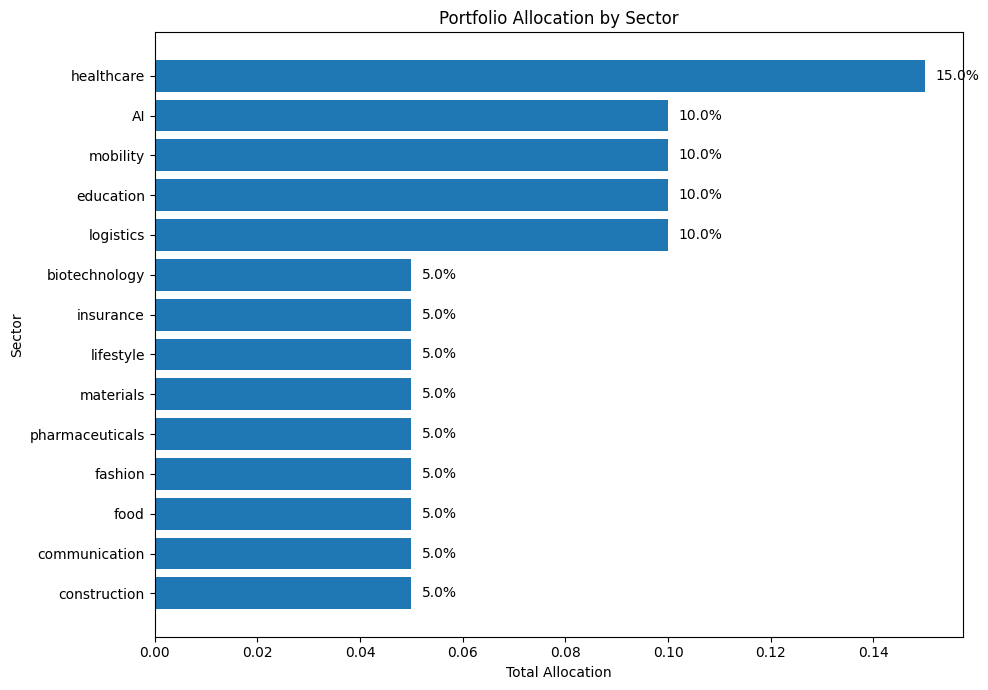

In [16]:
sector_portfolio = portfolio_df.merge(stocks, left_on="stock", right_on="stock_id")
sector_alloc = sector_portfolio.groupby("sector", as_index=False)["weight"].sum()
sector_alloc = sector_alloc.sort_values("weight", ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(sector_alloc["sector"], sector_alloc["weight"])

plt.xlabel("Total Allocation")
plt.ylabel("Sector")
plt.title("Portfolio Allocation by Sector")

for bar, value in zip(bars, sector_alloc["weight"]):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{value:.1%}", va="center")

plt.tight_layout()
plt.show()


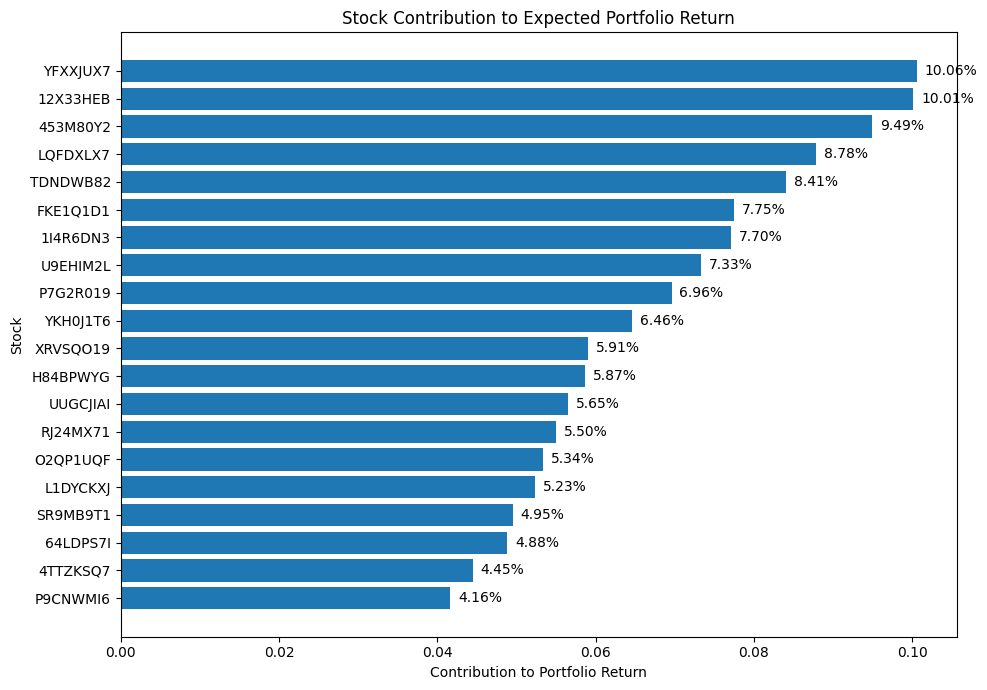

In [17]:
portfolio_analysis = portfolio_df.merge(
    df[["stock_id", "sector", "return"]],
    left_on="stock",
    right_on="stock_id",
    how="left"
)

portfolio_analysis["contribution"] = portfolio_analysis["weight"] * portfolio_analysis["return"]
portfolio_analysis = portfolio_analysis.sort_values("contribution", ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(portfolio_analysis["stock"], portfolio_analysis["contribution"])

plt.xlabel("Contribution to Portfolio Return")
plt.ylabel("Stock")
plt.title("Stock Contribution to Expected Portfolio Return")

for bar, value in zip(bars, portfolio_analysis["contribution"]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"{value:.2%}", va="center")

plt.tight_layout()
plt.show()


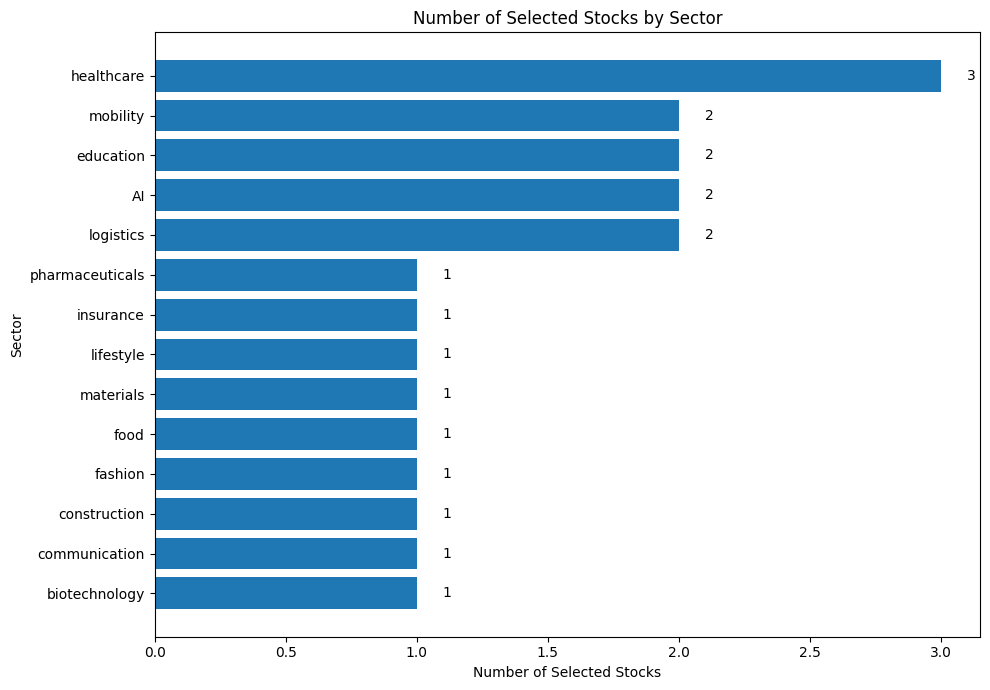

In [18]:
selected_count = (
    sector_portfolio.groupby("sector")["stock"]
    .count()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
bars = plt.barh(selected_count.index, selected_count.values)

plt.xlabel("Number of Selected Stocks")
plt.ylabel("Sector")
plt.title("Number of Selected Stocks by Sector")

for bar, value in zip(bars, selected_count.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(value), va="center")

plt.tight_layout()
plt.show()


## 4.1 - Strategy Sensitivity Analysis

To evaluate the robustness of the strategy, I will analyze alternative investment constraints. Examples of alternative scenarios include:

- increasing the maximum investment per stock
- changing sector allocation percentages

This analysis helps determine whether the portfolio performance is sensitive to the imposed constraints. Specifically, three limits are tested:

• 5% (baseline scenario)  
• 10%  
• 20%

For each scenario, the optimization model is solved again and the resulting expected portfolio return is recorded. This analysis helps understand how concentration limits influence the achievable portfolio performance.


In [19]:
# three scenarios
max_limits = [0.05, 0.10, 0.20]

results = []

# iterate over the three scenarios, maximize and find the best
for limit in max_limits:

    model = Model()
    x = model.addVars(stocks_list, lb=0, ub=limit)

    model.setObjective(
        quicksum(returns_dict[i] * x[i] for i in stocks_list),
        GRB.MAXIMIZE
    )
    model.addConstr(quicksum(x[i] for i in stocks_list) == 1)

    model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in top) == 0.5)
    model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in middle) == 0.3)
    model.addConstr(quicksum(x[i] for i in stocks_list if sector_dict[i] in bottom) == 0.2)

    model.optimize()

    # save current results 
    results.append(model.objVal)

# print results
results


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 4 rows, 500 columns and 1000 nonzeros (Max)
Model fingerprint: 0x981c948d
Model has 500 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e-04, 2e+00]
  Bounds range     [5e-02, 5e-02]
  RHS range        [2e-01, 1e+00]

Presolve time: 0.01s
Presolved: 4 rows, 500 columns, 1000 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.9167938e+00   8.500000e-01   0.000000e+00      0s
       3    1.3491650e+00   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.03 seconds (0.00 work units)
Optimal objective  1.349164988e+00
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model:

[1.3491649879873306, 1.5928384041268626, 1.786464011797026]

In [20]:
# sensitivity
sensitivity_df = pd.DataFrame({
    "max_weight": max_limits,
    "expected_return": results
})

sensitivity_df

,max_weight,expected_return
0,0.05,1.349165
1,0.10,1.592838
2,0.20,1.786464


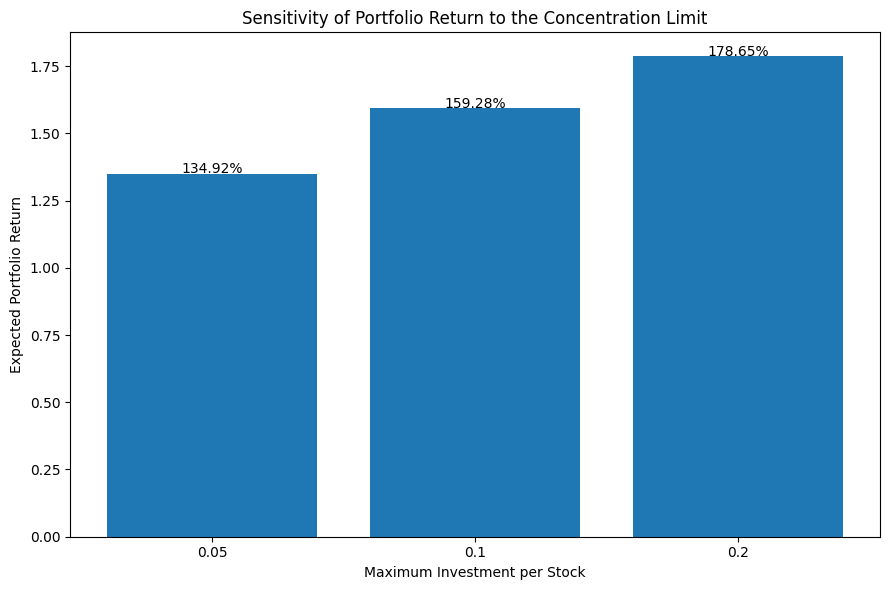

In [21]:
plt.figure(figsize=(9, 6))
bars = plt.bar(
    sensitivity_df["max_weight"].astype(str),
    sensitivity_df["expected_return"]
)

plt.xlabel("Maximum Investment per Stock")
plt.ylabel("Expected Portfolio Return")
plt.title("Sensitivity of Portfolio Return to the Concentration Limit")

for bar, value in zip(bars, sensitivity_df["expected_return"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()
